In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
#from scar import setup_anndata
import warnings
import anndata
import numpy as np
import os
#import bbknn
warnings.simplefilter("ignore")

In [2]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import anndata
import scvi
import scanpy as sc

sc.set_figure_params(figsize=(4, 4))
scvi.settings.seed = 94705

%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}
%config InlineBackend.figure_format='retina'

Global seed set to 0
Global seed set to 94705


## 2D data as reference

### Preprocessing/Subsetting original data

In [4]:
adata_ref = sc.read('/wynton/group/pollen/jding/brainchromatin/HM2D/D7-filtered_guides.IN.h5ad')

In [5]:
adata_ref

AnnData object with n_obs × n_vars = 17333 × 38593
    obs: 'batch_name', 'GRCh38', 'rheMac10', 'call', 'species', 'individual-Q', 'individual', 'sgRNA_NKS', 'num_guide_IDs', 'log', 'clone_barcode', 'clone_barcode_criteria', 'batch', 'percent_ribo', 'percent_mito', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'gene_NKS', 'num_gene_NKS', 'sgRNA', 'num_sgRNA', 'sgRNA_effecitve', 'timepoint', 'stage', 'sample_id', 'sex', 'species_batch', 'Ident', '_scvi_batch', '_scvi_labels', 'labels_scanvi', 'leiden', 'leiden-.2', 'leiden-.3', 'leiden-.8', 'predictions', 'timepoint_batch_name', 'class', 'leiden-.4', 'supervised_name', 'subtype'
    var: 'gene_ids-HD0', 'feature_types-HD0', 'genome-HD0', 'mt-HD0', 'n_cells_by_counts-HD0', 'mean_counts-HD0', 'pct_dropout_by_counts-HD0', 'total_counts-HD0', 'gene_ids-HD7', 'feature_types-HD7', 'genome-HD7', 'mt-HD7', 'n_cells_by_counts-HD7', 'mean_counts-HD7', 'pct_dropout_by_counts-HD7', 'total_counts-HD7', 'gene_ids

In [6]:
adata_ref.layers["counts"] = adata_ref.X.copy()
adata_ref.raw = adata_ref

In [7]:
sc.pp.normalize_total(adata_ref,exclude_highly_expressed=True)
sc.pp.log1p(adata_ref)
sc.pp.highly_variable_genes(adata_ref, n_top_genes=2500, batch_key="Ident", subset= True)
#adata_ref.var['highly_variable']=[x for x in adata_ref.var['highly_variable'] if x in adata_query.var_names]

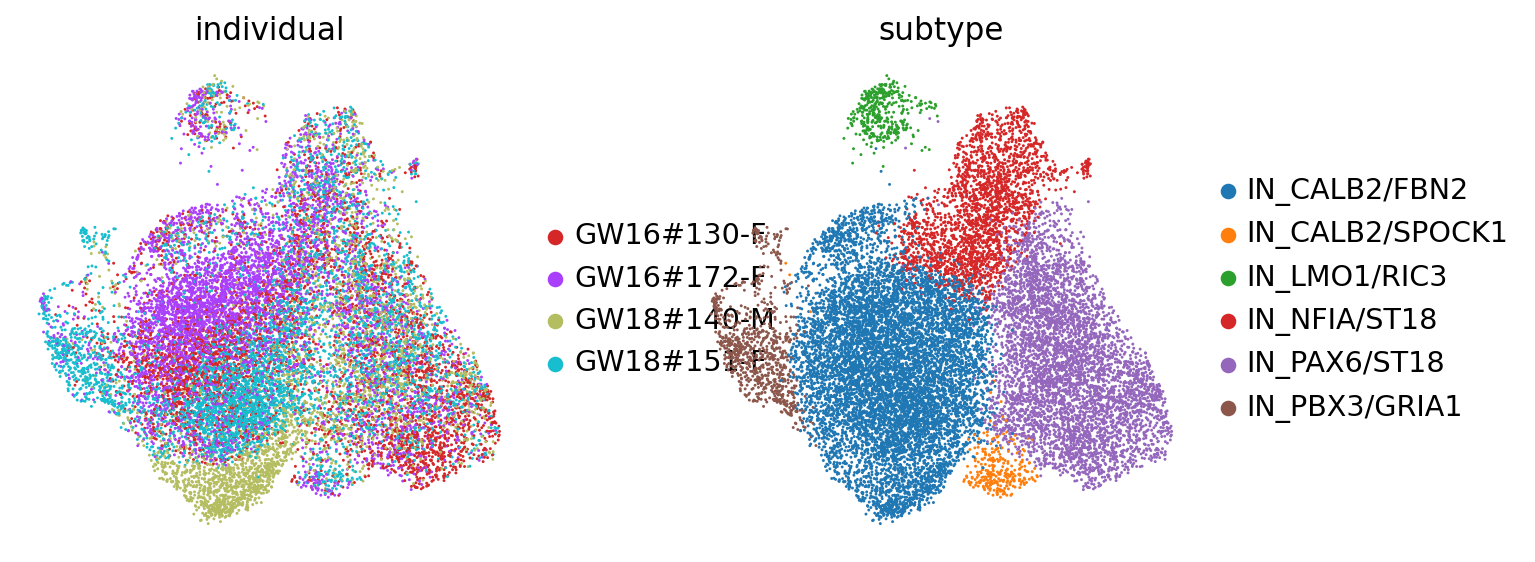

In [8]:
sc.pl.umap(
    adata_ref,
    color=[ "individual",'subtype'],
    frameon=False,
)

In [61]:
adata_ref.obs['subtype'].value_counts()

IN_CALB2/FBN2      8726
IN_PAX6/ST18       4819
IN_NFIA/ST18       2275
IN_PBX3/GRIA1       839
IN_LMO1/RIC3        381
IN_CALB2/SPOCK1     293
Name: subtype, dtype: int64

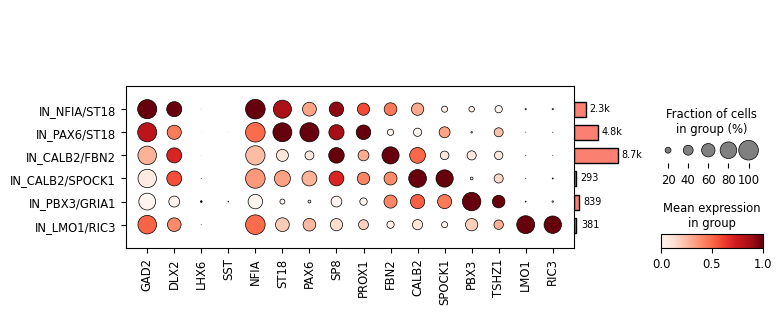

In [82]:
adata_ref.obs['subtype'] = adata_ref.obs['subtype'].astype('category')
dp = sc.pl.dotplot(adata_ref, ['GAD2','DLX2','LHX6','SST','NFIA','ST18',
                          'PAX6','SP8','PROX1','FBN2','CALB2','SPOCK1','PBX3','TSHZ1','LMO1','RIC3'], 
                   'subtype', cmap='Reds' ,
                   categories_order = ['IN_NFIA/ST18','IN_PAX6/ST18','IN_CALB2/FBN2','IN_CALB2/SPOCK1','IN_PBX3/GRIA1','IN_LMO1/RIC3'],
                                 standard_scale='var',dot_max=0.6, return_fig=True)
dp.add_totals().style(dot_edge_color='black', dot_edge_lw=0.5, cmap='Reds').savefig("./figures/dotplot-IN.pdf")

### Import query data

In [3]:
#subset data for 2D IN lineage
import scanpy as sc 
adata_query = sc.read('/wynton/group/pollen/jding/brainchromatin/HM2D/HM2D-filtered.h5ad')
adata_query.obs['sex'] = [x.split('-')[-1] for x in adata_query.obs['individual']]
adata_query.obs['stage'] = [x.split('#')[0] for x in adata_query.obs['individual']]
adata_query.obs['perturbation'] = ['NT' if x in ['WT','non-targeting'] else 'Perturbed' for x in adata_query.obs['gene_NKS']]
adata_query = adata_query[adata_query.obs['supervised_name'].isin(['IN_dLGE-CGE'])]

In [9]:
adata_query.raw = adata_query.copy()
adata_query.layers['counts'] = adata_query.X

In [10]:
adata_ref.var_names_make_unique()
adata_query.var_names_make_unique()

In [11]:
sc.pp.normalize_total(adata_query, target_sum=1e4,exclude_highly_expressed=True)
sc.pp.log1p(adata_query)
sc.pp.highly_variable_genes(adata_query, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.scale(adata_query, max_value=10)
sc.pp.highly_variable_genes(adata_query, n_top_genes=2500, batch_key="batch_name", subset= False)

In [12]:
var = [x for x in adata_ref.var_names if x in adata_query.var_names]
adata_ref = adata_ref[:, var].copy()
adata_query = adata_query[:, var].copy()

In [13]:
scvi.model.SCVI.setup_anndata(adata_ref, batch_key="individual", layer="counts")

arches_params = dict(
    use_layer_norm="both",
    use_batch_norm="none",
    encode_covariates=True,
    dropout_rate=0.2,
    n_layers=2,
)

vae_ref = scvi.model.SCVI(
    adata_ref,
    **arches_params
)
vae_ref.train()

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Epoch 400/400: 100%|█████| 400/400 [1:06:48<00:00,  9.91s/it, loss=768, v_num=1]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|█████| 400/400 [1:06:48<00:00, 10.02s/it, loss=768, v_num=1]


In [14]:
adata_ref.obsm["X_scVI"] = vae_ref.get_latent_representation()
sc.pp.neighbors(adata_ref, use_rep="X_scVI")
sc.tl.leiden(adata_ref)
sc.tl.umap(adata_ref)

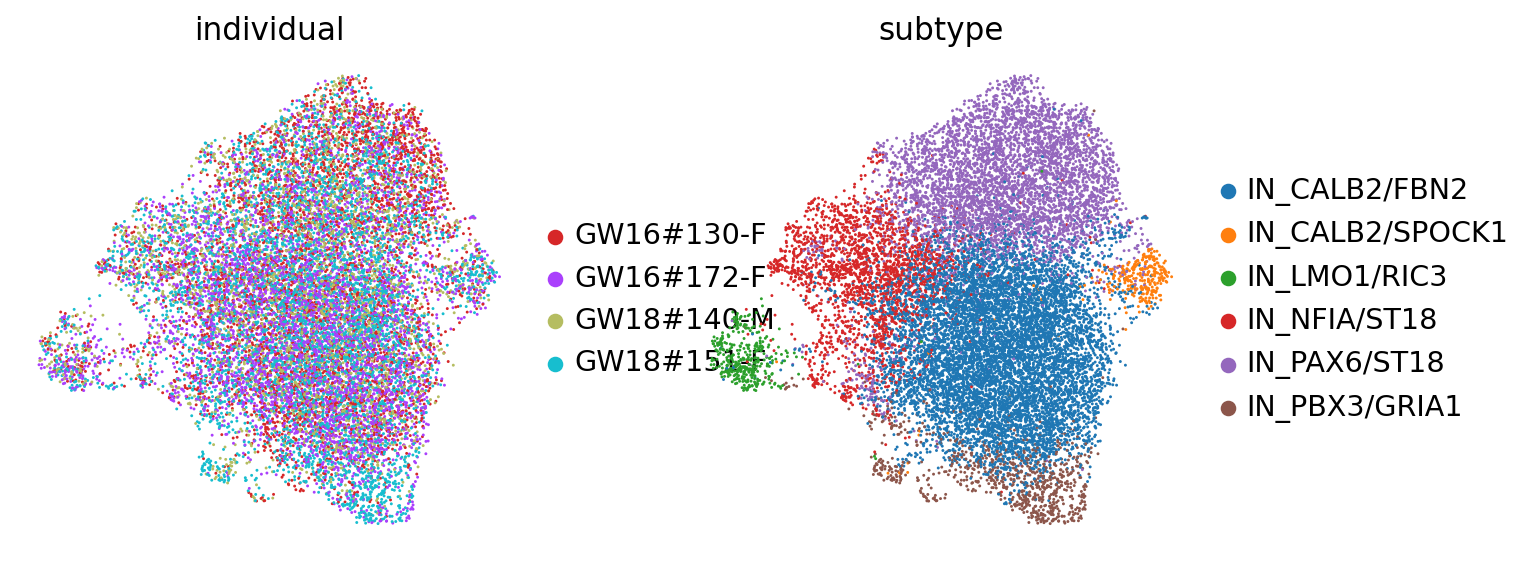

In [15]:
sc.pl.umap(
    adata_ref,
    color=[ "individual",'subtype'],
    frameon=False,
)

In [16]:
# save the reference model
directory='/wynton/group/pollen/jding/brainchromatin/Li/'
directory='/wynton/scratch/jding/brainchromatin/Li/'
dir_path = os.path.join(directory,'scVI_model_IN/')
vae_ref.save(dir_path, overwrite=True)

In [17]:
# load the reference model
directory='/wynton/group/pollen/jding/brainchromatin/Li/'
directory='/wynton/scratch/jding/brainchromatin/Li/'
dir_path = os.path.join(directory,'scVI_model_IN/')
vae_ref = scvi.model.SCVI.load(dir_path,adata_ref)

INFO     File /wynton/scratch/jding/brainchromatin/Li/scVI_model_IN/model.pt already downloaded                    


In [18]:
# both are valid
scvi.model.SCVI.prepare_query_anndata(adata_query, dir_path)
#scvi.model.SCVI.prepare_query_anndata(adata_query, vae_ref)

INFO     File /wynton/scratch/jding/brainchromatin/Li/scVI_model_IN/model.pt already downloaded                    
INFO     Found 100.0% reference vars in query data.                                                                


In [19]:
adata_query.obs['Ident'] = adata_query.obs['batch_name']

In [20]:
# both are valid
vae_q = scvi.model.SCVI.load_query_data(
    adata_query,
    dir_path,
)
vae_q = scvi.model.SCVI.load_query_data(
    adata_query,
    vae_ref,
)

INFO     File /wynton/scratch/jding/brainchromatin/Li/scVI_model_IN/model.pt already downloaded                    


In [21]:
vae_q.train(max_epochs=200, plan_kwargs=dict(weight_decay=0.0))
adata_query.obsm["X_scVI"] = vae_q.get_latent_representation()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Epoch 200/200: 100%|███████| 200/200 [41:25<00:00, 12.16s/it, loss=572, v_num=1]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200: 100%|███████| 200/200 [41:25<00:00, 12.43s/it, loss=572, v_num=1]


In [22]:
sc.pp.neighbors(adata_query, use_rep="X_scVI")
sc.tl.leiden(adata_query)
sc.tl.umap(adata_query)

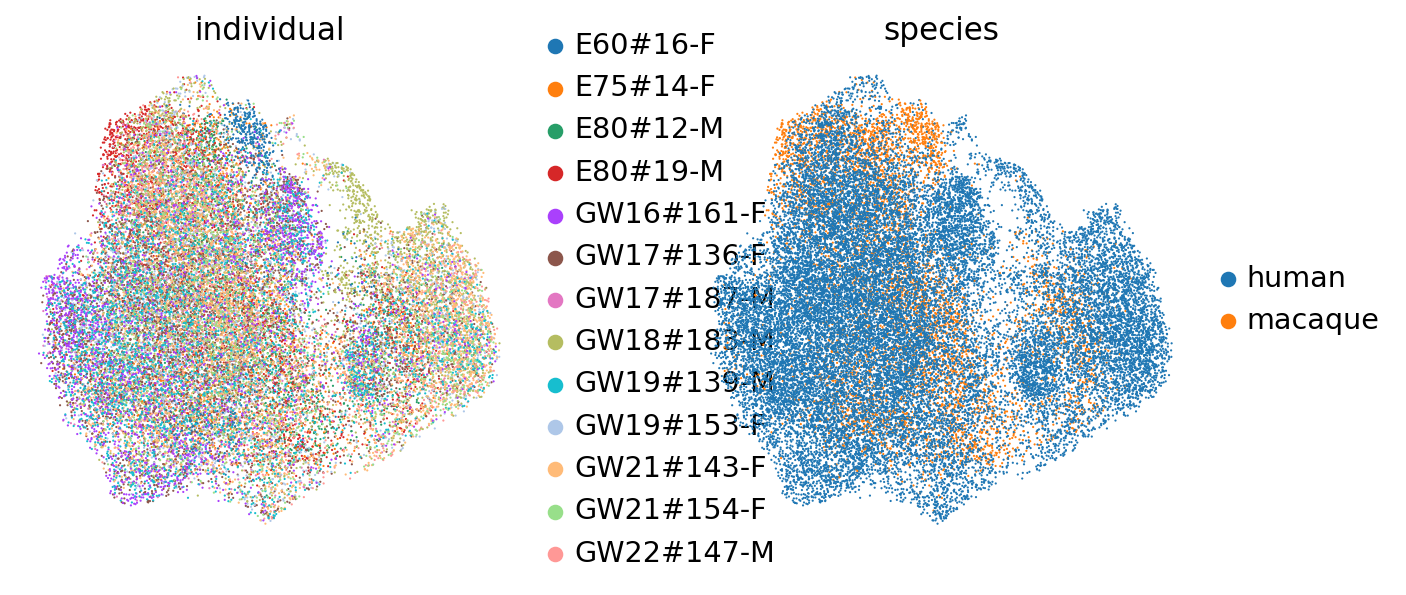

In [23]:
sc.pl.umap(
    adata_query,
    color=[ "individual",'species'],
    frameon=False,
)

In [ ]:
directory='/wynton/group/pollen/jding/brainchromatin/Li/'
adata_ref.write(os.path.join(directory,'ref.h5ad'), compression='gzip')

### Reference mapping from 2D with SCANVI

In [24]:
adata_ref.obs["labels_scanvi"] = adata_ref.obs["subtype"].values

In [25]:
directory='/wynton/group/pollen/jding/brainchromatin/Li/'
directory='/wynton/scratch/jding/brainchromatin/Li/'
dir_path = os.path.join(directory,'scVI_model_IN/')
vae_ref = scvi.model.SCVI.load(dir_path, adata_ref)

INFO     File /wynton/scratch/jding/brainchromatin/Li/scVI_model_IN/model.pt already downloaded                    


In [26]:
# unlabeled category does not exist in adata.obs[labels_key]
# so all cells are treated as labeled
vae_ref_scan = scvi.model.SCANVI.from_scvi_model(
    vae_ref,
    unlabeled_category="Unknown",
    labels_key="labels_scanvi",
)

In [27]:
vae_ref_scan.train(max_epochs=20, n_samples_per_label=100)

INFO     Training for 20 epochs.                                                                                   


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Epoch 20/20: 100%|███████████| 20/20 [04:04<00:00, 12.03s/it, loss=811, v_num=1]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 20/20: 100%|███████████| 20/20 [04:04<00:00, 12.23s/it, loss=811, v_num=1]


In [28]:
adata_ref.obsm["X_scANVI"] = vae_ref_scan.get_latent_representation()
sc.pp.neighbors(adata_ref, use_rep="X_scANVI")
sc.tl.leiden(adata_ref)
sc.tl.umap(adata_ref)

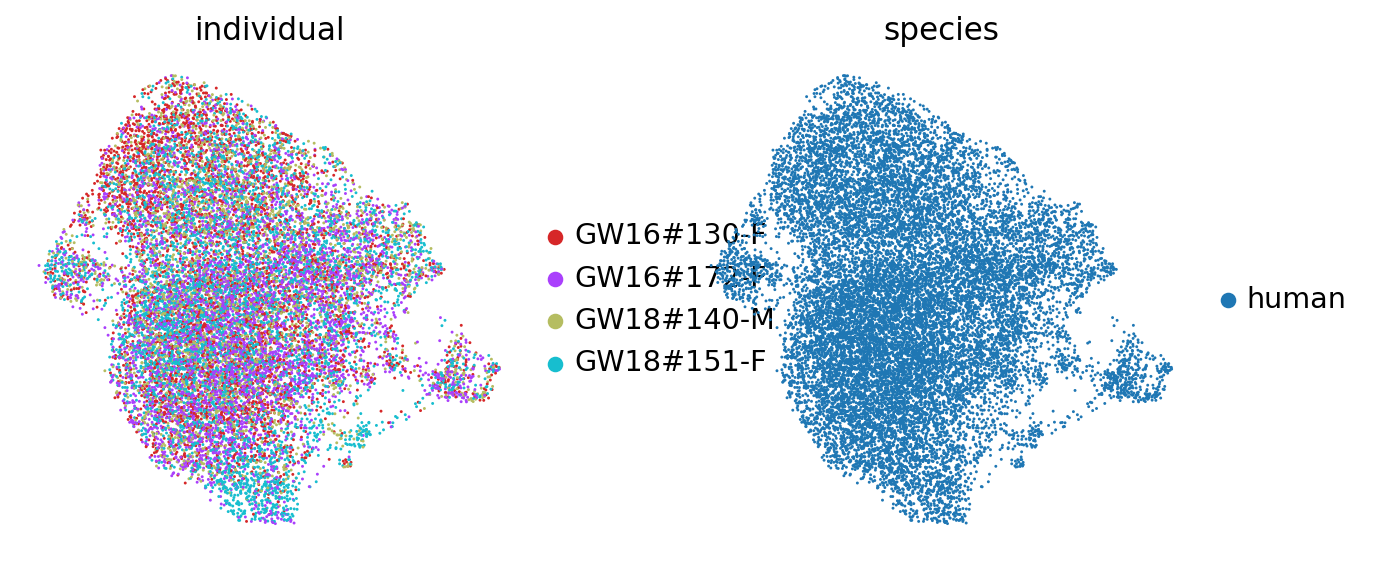

In [29]:
sc.pl.umap(
    adata_ref,
    color=[ "individual",'species'],
    frameon=False,
)

In [30]:
# save the reference model
directory='/wynton/group/pollen/jding/brainchromatin/Li/'
directory='/wynton/scratch/jding/brainchromatin/Li/'
dir_path_scan = os.path.join(directory,'scanvi_model_IN/')
vae_ref_scan.save(dir_path_scan, overwrite=True)

In [31]:
# load the reference model
directory='/wynton/group/pollen/jding/brainchromatin/Li/'
directory='/wynton/scratch/jding/brainchromatin/Li/'
dir_path_scan = os.path.join(directory,'scanvi_model_IN/')
vae_ref_scan = scvi.model.SCANVI.load(dir_path_scan,adata_ref)

INFO     File /wynton/scratch/jding/brainchromatin/Li/scanvi_model_IN/model.pt already downloaded                  


In [32]:
# again a no-op in this tutorial, but good practice to use
scvi.model.SCANVI.prepare_query_anndata(adata_query, dir_path_scan)

INFO     File /wynton/scratch/jding/brainchromatin/Li/scanvi_model_IN/model.pt already downloaded                  
INFO     Found 100.0% reference vars in query data.                                                                


In [33]:
vae_q = scvi.model.SCANVI.load_query_data(adata_query,vae_ref_scan)

In [34]:
vae_q.train(
    max_epochs=100,
    plan_kwargs=dict(weight_decay=0.0),
    check_val_every_n_epoch=10,
)

INFO     Training for 100 epochs.                                                                                  


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Epoch 100/100: 100%|███████| 100/100 [23:56<00:00, 14.64s/it, loss=569, v_num=1]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|███████| 100/100 [23:56<00:00, 14.36s/it, loss=569, v_num=1]


In [35]:
# save the query model
directory='/wynton/group/pollen/jding/brainchromatin/Li/'
directory='/wynton/scratch/jding/brainchromatin/Li/'
dir_path_scan = os.path.join(directory,'scanvi_model_IN_query/')
vae_q.save(dir_path_scan, overwrite=True)

In [36]:
adata_query.obsm["X_scANVI"] = vae_q.get_latent_representation()
adata_query.obs["predictions"] = vae_q.predict()

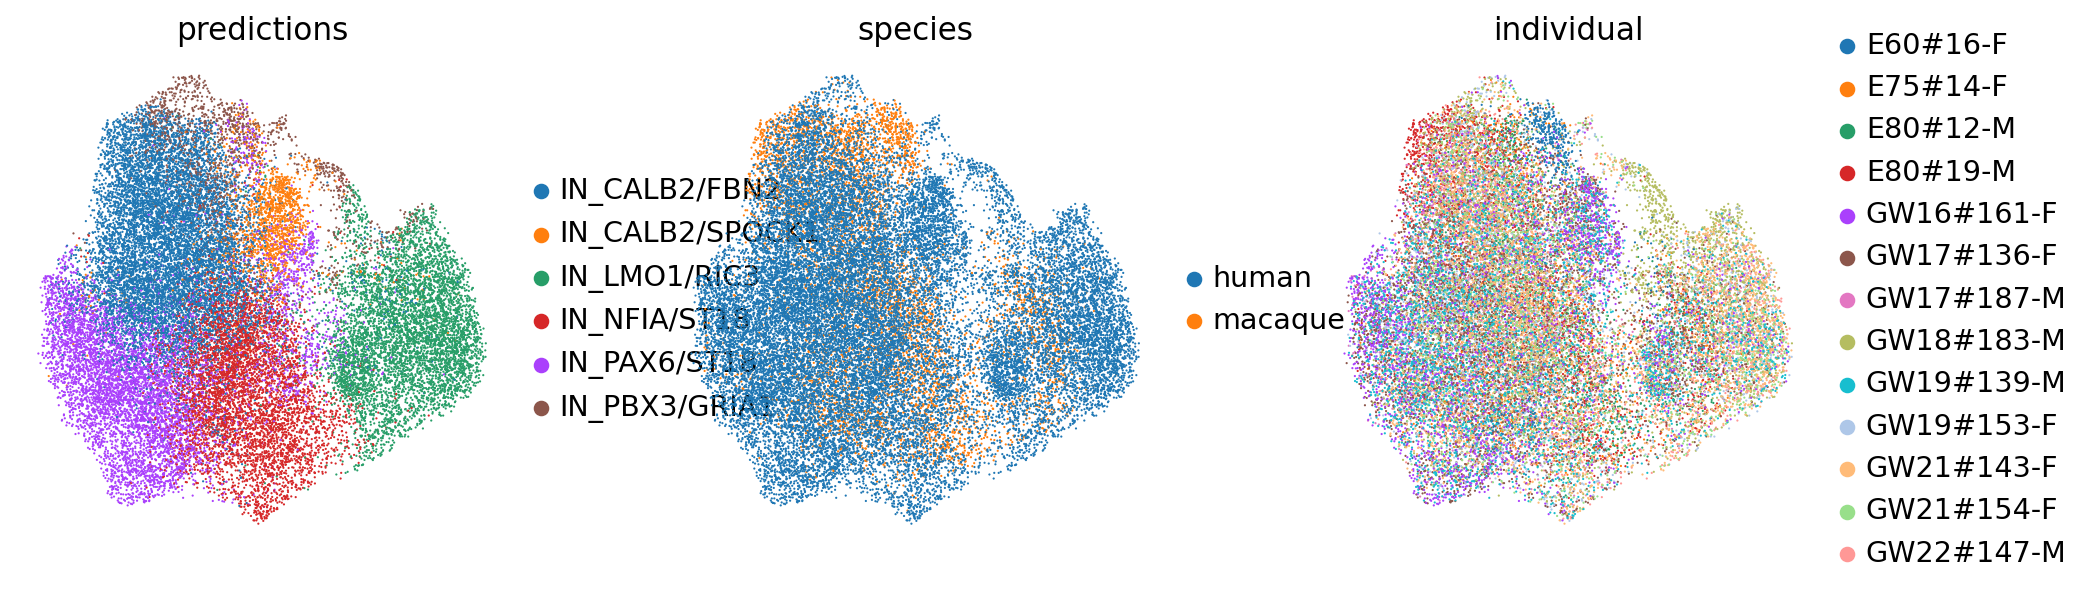

In [37]:
sc.pl.umap(adata_query,color=["predictions",'species','individual'],frameon=False,ncols=3)

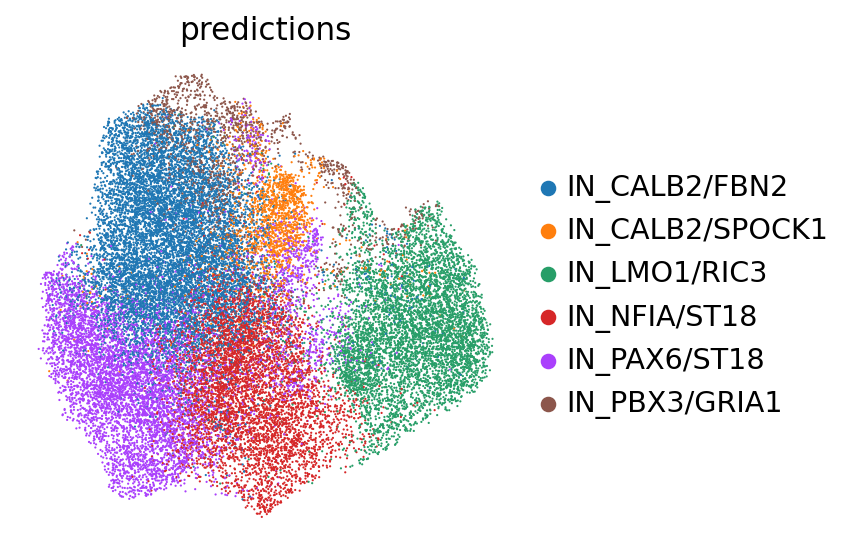

In [38]:
sc.pl.umap(adata_query,color=["predictions"],frameon=False,ncols=3)

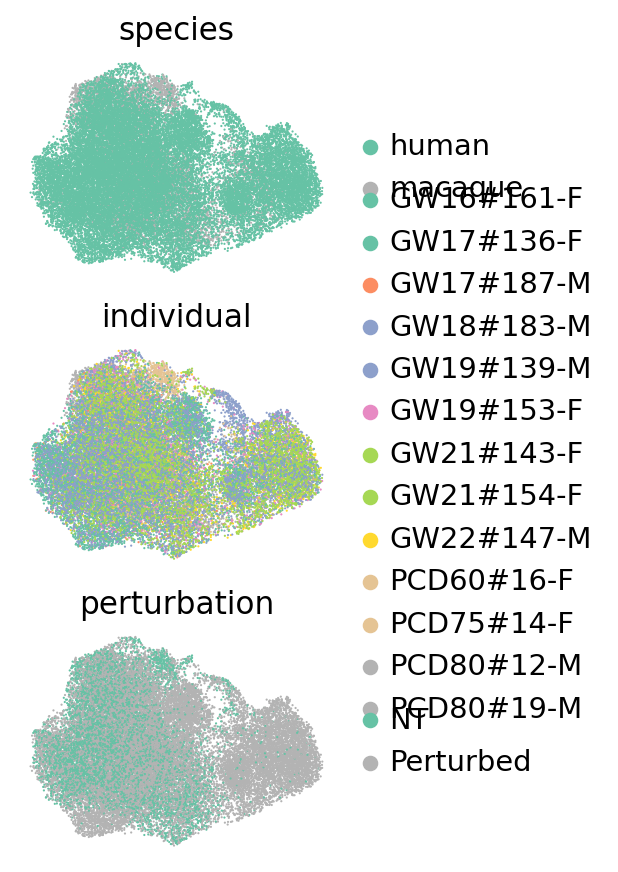

In [44]:
from matplotlib import rcParams
rcParams["figure.figsize"] = (2, 2)
adata_query.obs['perturbation'] = ['NT' if x in ['WT','non-targeting'] else 'Perturbed' for x in adata_query.obs['gene_NKS']]
adata_query.obs['individual'] = adata_query.obs['individual'].str.replace('E', 'PCD', regex=False)
sc.pl.umap(adata_query, color=['species','individual','perturbation'],frameon=False, legend_fontsize=13, legend_fontoutline=3,
           palette='Set2',ncols=1,save='IN_distribution_HM2D'
          )

In [39]:
adata_query.raw.to_adata().write('/wynton/group/pollen/jding/brainchromatin/Li/HM2D_IN_query.h5ad')

In [4]:
import scanpy as sc
adata =  sc.read('/wynton/group/pollen/jding/brainchromatin/Li/HM2D_IN_query.h5ad')
sc.pp.normalize_total(adata,exclude_highly_expressed=True)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.scale(adata,max_value=10)
sc.pp.pca(adata,n_comps=100)

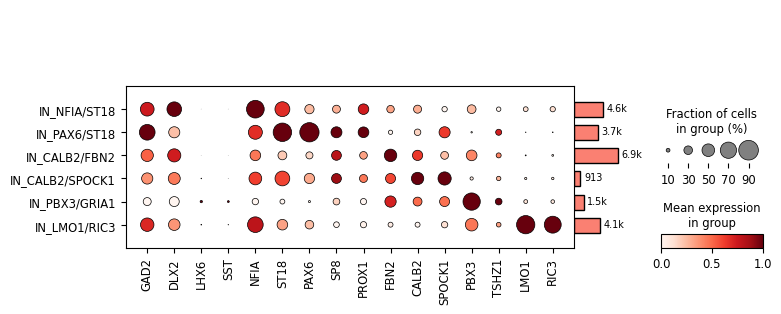

In [84]:
adata.obs['predictions'] = adata.obs['predictions'].astype('category')
dp = sc.pl.dotplot(adata, ['GAD2','DLX2','LHX6','SST','NFIA','ST18',
                          'PAX6','SP8','PROX1','FBN2','CALB2','SPOCK1','PBX3','TSHZ1','LMO1','RIC3'], 
                   'predictions', cmap='Reds' ,
                   categories_order = ['IN_NFIA/ST18','IN_PAX6/ST18','IN_CALB2/FBN2','IN_CALB2/SPOCK1','IN_PBX3/GRIA1','IN_LMO1/RIC3'],
                                 standard_scale='var',dot_max=0.6, return_fig=True)
dp.add_totals().style(dot_edge_color='black', dot_edge_lw=0.5, cmap='Reds').savefig("./figures/dotplot-IN-HM2D.pdf")

In [5]:
HALLMARK_GLYCOLYSIS = ["ABCB6","ADORA2B","AGL","AGRN","AK3","AK4","AKR1A1","ALDH7A1","ALDH9A1","ALDOA","ALDOB","ALG1","ANG","ANGPTL4","ANKZF1","ARPP19","ARTN","AURKA","B3GALT6","B3GAT1","B3GAT3","B3GNT3","B4GALT1","B4GALT2","B4GALT4","B4GALT7","BIK","BPNT1","CACNA1H","CAPN5","CASP6","CD44","CDK1","CENPA","CHPF","CHPF2","CHST1","CHST12","CHST2","CHST4","CHST6","CITED2","CLDN3","CLDN9","CLN6","COG2","COL5A1","COPB2","CTH","CXCR4","CYB5A","DCN","DDIT4","DEPDC1","DLD","DPYSL4","DSC2","ECD","EFNA3","EGFR","EGLN3","ELF3","ENO1","ENO2","ERO1A","EXT1","EXT2","FAM162A","FBP2","FKBP4","FUT8","G6PD","GAL3ST1","GALE","GALK1","GALK2","GAPDHS","GCLC","GFPT1","GFUS","GLCE","GLRX","GMPPA","GMPPB","GNE","GNPDA1","GOT1","GOT2","GPC1","GPC3","GPC4","GPR87","GUSB","GYS1","GYS2","HAX1","HDLBP","HK2","HMMR","HOMER1","HS2ST1","HS6ST2","HSPA5","IDH1","IDUA","IER3","IGFBP3","IL13RA1","IRS2","ISG20","KDELR3","KIF20A","KIF2A","LCT","LDHA","LDHC","LHPP","LHX9","MDH1","MDH2","ME1","ME2","MED24","MERTK","MET","MIF","MIOX","MPI","MXI1","NANP","NASP","NDST3","NDUFV3","NOL3","NSDHL","NT5E","P4HA1","P4HA2","PAM","PAXIP1","PC","PDK3","PFKFB1","PFKP","PGAM1","PGAM2","PGK1","PGLS","PGM2","PHKA2","PKM","PKP2","PLOD1","PLOD2","PMM2","POLR3K","PPFIA4","PPIA","PPP2CB","PRPS1","PSMC4","PYGB","PYGL","QSOX1","RARS1","RBCK1","RPE","RRAGD","SAP30","SDC1","SDC2","SDC3","SDHC","SLC16A3","SLC25A10","SLC25A13","SLC35A3","SLC37A4","SOD1","SOX9","SPAG4","SRD5A3","STC1","STC2","STMN1","TALDO1","TFF3","TGFA","TGFBI","TKTL1","TPBG","TPI1","TPST1","TXN","UGP2","VCAN","VEGFA","VLDLR","XYLT2","ZNF292"]
sc.tl.score_genes(adata, HALLMARK_GLYCOLYSIS, score_name='Glycolysis')
HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY = ["ABCC1","ATOX1","CAT","CDKN2D","EGLN2","ERCC2","FES","FTL","G6PD","GCLC","GCLM","GLRX","GLRX2","GPX3","GPX4","GSR","HHEX","HMOX2","IPCEF1","JUNB","LAMTOR5","LSP1","MBP","MGST1","MPO","MSRA","NDUFA6","NDUFB4","NDUFS2","NQO1","OXSR1","PDLIM1","PFKP","PRDX1","PRDX2","PRDX4","PRDX6","PRNP","PTPA","SBNO2","SCAF4","SELENOS","SOD1","SOD2","SRXN1","STK25","TXN","TXNRD1","TXNRD2"]
sc.tl.score_genes(adata, HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY, score_name='ROS')
RESPONSE_TO_ER_STRESS = ["ABCA7","ABL1","AFF4","AGR2","AIFM1","ALOX15","ALOX5","AMFR","ANKS4B","ANKZF1","APAF1","AQP11","ATF3","ATF4","ATF6","ATF6B","ATG10","ATP2A1","ATP2A2","ATP2A3","ATXN3","AUP1","BAG6","BAK1","BAX","BBC3","BCAP31","BCL2","BCL2L1","BCL2L11","BFAR","BHLHA15","BOK","BRSK2","CALR","CALR3","CANX","CASP4","CAV1","CCDC47","CCND1","CDK5RAP3","CEBPB","CERT1","CFTR","CHAC1","CLGN","CLU","COPS5","CREB3","CREB3L1","CREB3L2","CREB3L3","CREBZF","CTH","CXCL8","DAB2IP","DDIT3","DDRGK1","DDX3X","DERL1","DERL2","DERL3","DNAJB12","DNAJB2","DNAJB9","DNAJC10","DNAJC3","ECPAS","EDEM1","EDEM2","EDEM3","EIF2AK2","EIF2AK3","EIF2AK4","EIF2B5","EIF2S1","EIF4G1","ELAVL4","ERLEC1","ERLIN1","ERLIN2","ERMP1","ERN1","ERN2","ERO1A","ERP27","ERP29","ERP44","FAF1","FAF2","FAM8A1","FBXO17","FBXO2","FBXO27","FBXO44","FBXO6","FCGR2B","FGF21","FICD","FLOT1","FOXRED2","GET4","GORASP2","GRINA","GSK3B","HERPUD1","HERPUD2","HM13","HSP90B1","HSPA1A","HSPA5","HYOU1","ITPR1","JKAMP","JUN","KCNJ8","LPCAT3","LRRK2","MAGEA3","MAN1A1","MAN1A2","MAN1B1","MAN1C1","MANF","MAP3K5","MARCHF6","MARCKS","MBTPS1","MBTPS2","MIR199A1","MIR200C","NCCRP1","NCK1","NCK2","NFE2L2","NHLRC1","NIBAN1","NOD1","NOD2","NPLOC4","NR1H2","NR1H3","NRBF2","NUPR1","OPA1","OS9","P4HB","PARK7","PARP16","PARP6","PARP8","PDIA2","PDIA3","PDIA4","PDIA6","PDX1","PIGBOS1","PIK3R1","PIK3R2","PMAIP1","PML","PPP1R15A","PPP1R15B","PPP2CB","PRKN","PSMC6","PTPN1","PTPN2","QRICH1","RACK1","RASGRF1","RASGRF2","RCN3","RHBDD1","RHBDD2","RNF103","RNF121","RNF139","RNF175","RNF183","RNF185","RNF186","RNF5","RNFT1","RNFT2","RPAP2","SCAMP5","SDF2L1","SEC16A","SEC61B","SEL1L","SEL1L2","SELENOK","SELENOS","SERINC3","SERP1","SERP2","SESN2","SGF29","SGTA","SIRT1","SRPX","STC2","STT3B","STUB1","SVIP","SYVN1","TARDBP","TBL2","THBS1","THBS4","TMBIM6","TMCO1","TMED2","TMEM117","TMEM129","TMEM238L","TMEM258","TMEM259","TMEM33","TMEM67","TMTC3","TMTC4","TMUB1","TMUB2","TMX1","TNFRSF10B","TOR1A","TP53","TRAF2","TRIB3","TRIM13","TRIM25","TTC23L","TXNDC12","UBA5","UBAC2","UBE2G2","UBE2J1","UBE2J2","UBE4A","UBE4B","UBQLN1","UBQLN2","UBXN1","UBXN10","UBXN2A","UBXN4","UBXN6","UBXN8","UFC1","UFD1","UFL1","UFM1","UGGT1","UGGT2","UMOD","USP13","USP14","USP19","USP25","VAPB","VCP","WFS1","XBP1","YOD1"]
sc.tl.score_genes(adata, RESPONSE_TO_ER_STRESS,score_name='ER')
HALLMARK_APOPTOSIS = ["ADD1","AIFM3","ANKH","ANXA1","APP","ATF3","AVPR1A","BAX","BCAP31","BCL10","BCL2L1","BCL2L10","BCL2L11","BCL2L2","BGN","BID","BIK","BIRC3","BMF","BMP2","BNIP3L","BRCA1","BTG2","BTG3","CASP1","CASP2","CASP3","CASP4","CASP6","CASP7","CASP8","CASP9","CAV1","CCNA1","CCND1","CCND2","CD14","CD2","CD38","CD44","CD69","CDC25B","CDK2","CDKN1A","CDKN1B","CFLAR","CLU","CREBBP","CTH","CTNNB1","CYLD","DAP","DAP3","DCN","DDIT3","DFFA","DIABLO","DNAJA1","DNAJC3","DNM1L","DPYD","EBP","EGR3","EMP1","ENO2","ERBB2","ERBB3","EREG","ETF1","F2","F2R","FAS","FASLG","FDXR","FEZ1","GADD45A","GADD45B","GCH1","GNA15","GPX1","GPX3","GPX4","GSN","GSR","GSTM1","GUCY2D","H1-0","HGF","HMGB2","HMOX1","HSPB1","IER3","IFITM3","IFNB1","IFNGR1","IGF2R","IGFBP6","IL18","IL1A","IL1B","IL6","IRF1","ISG20","JUN","KRT18","LEF1","LGALS3","LMNA","LUM","MADD","MCL1","MGMT","MMP2","NEDD9","NEFH","PAK1","PDCD4","PDGFRB","PEA15","PLAT","PLCB2","PLPPR4","PMAIP1","PPP2R5B","PPP3R1","PPT1","PRF1","PSEN1","PSEN2","PTK2","RARA","RELA","RETSAT","RHOB","RHOT2","RNASEL","ROCK1","SAT1","SATB1","SC5D","SLC20A1","SMAD7","SOD1","SOD2","SPTAN1","SQSTM1","TAP1","TGFB2","TGFBR3","TIMP1","TIMP2","TIMP3","TNF","TNFRSF12A","TNFSF10","TOP2A","TSPO","TXNIP","VDAC2","WEE1","XIAP"]
sc.tl.score_genes(adata, HALLMARK_APOPTOSIS,score_name='Apoptosis')
REACTOME_CELLULAR_SENESCENCE = ["ACD","AGO1","AGO3","AGO4","ANAPC1","ANAPC10","ANAPC11","ANAPC15","ANAPC16","ANAPC2","ANAPC4","ANAPC5","ANAPC7","ASF1A","ATM","BMI1","CABIN1","CBX2","CBX4","CBX6","CBX8","CCNA1","CCNA2","CCNE1","CCNE2","CDC16","CDC23","CDC26","CDC27","CDK2","CDK4","CDK6","CDKN1A","CDKN1B","CDKN2A","CDKN2B","CDKN2C","CDKN2D","CEBPB","CXCL8","E2F1","E2F2","E2F3","EED","EHMT1","EHMT2","EP400","ERF","ETS1","ETS2","EZH2","FOS","FZR1","H1-0","H1-1","H1-2","H1-3","H1-4","H1-5","H2AB1","H2AC14","H2AC18","H2AC19","H2AC20","H2AC4","H2AC6","H2AC7","H2AC8","H2AJ","H2AX","H2AZ2","H2BC1","H2BC10","H2BC11","H2BC12","H2BC12L","H2BC13","H2BC14","H2BC15","H2BC17","H2BC21","H2BC26","H2BC3","H2BC4","H2BC5","H2BC6","H2BC7","H2BC8","H2BC9","H3-3A","H3-3B","H3-4","H3C1","H3C10","H3C11","H3C12","H3C13","H3C14","H3C15","H3C2","H3C3","H3C4","H3C6","H3C7","H3C8","H4C1","H4C11","H4C12","H4C13","H4C14","H4C15","H4C16","H4C2","H4C3","H4C4","H4C5","H4C6","H4C8","H4C9","HIRA","HMGA1","HMGA2","ID1","IFNB1","IGFBP7","IL1A","IL6","JUN","KAT5","KDM6B","LMNB1","MAP2K3","MAP2K4","MAP2K6","MAP2K7","MAP3K5","MAP4K4","MAPK1","MAPK10","MAPK11","MAPK14","MAPK3","MAPK7","MAPK8","MAPK9","MAPKAPK2","MAPKAPK3","MAPKAPK5","MDM2","MDM4","MINK1","MIR24-1","MIR24-2","MOV10","MRE11","NBN","NFKB1","PHC1","PHC2","PHC3","POT1","RAD50","RB1","RBBP4","RBBP7","RELA","RING1","RNF2","RPS27A","RPS6KA1","RPS6KA2","RPS6KA3","SCMH1","SP1","STAT3","SUZ12","TERF1","TERF2","TERF2IP","TFDP1","TFDP2","TINF2","TNIK","TNRC6A","TNRC6B","TNRC6C","TP53","TXN","UBA52","UBB","UBC","UBE2C","UBE2D1","UBE2E1","UBE2S","UBN1","VENTX"]
sc.tl.score_genes(adata, REACTOME_CELLULAR_SENESCENCE,score_name='Senescence')

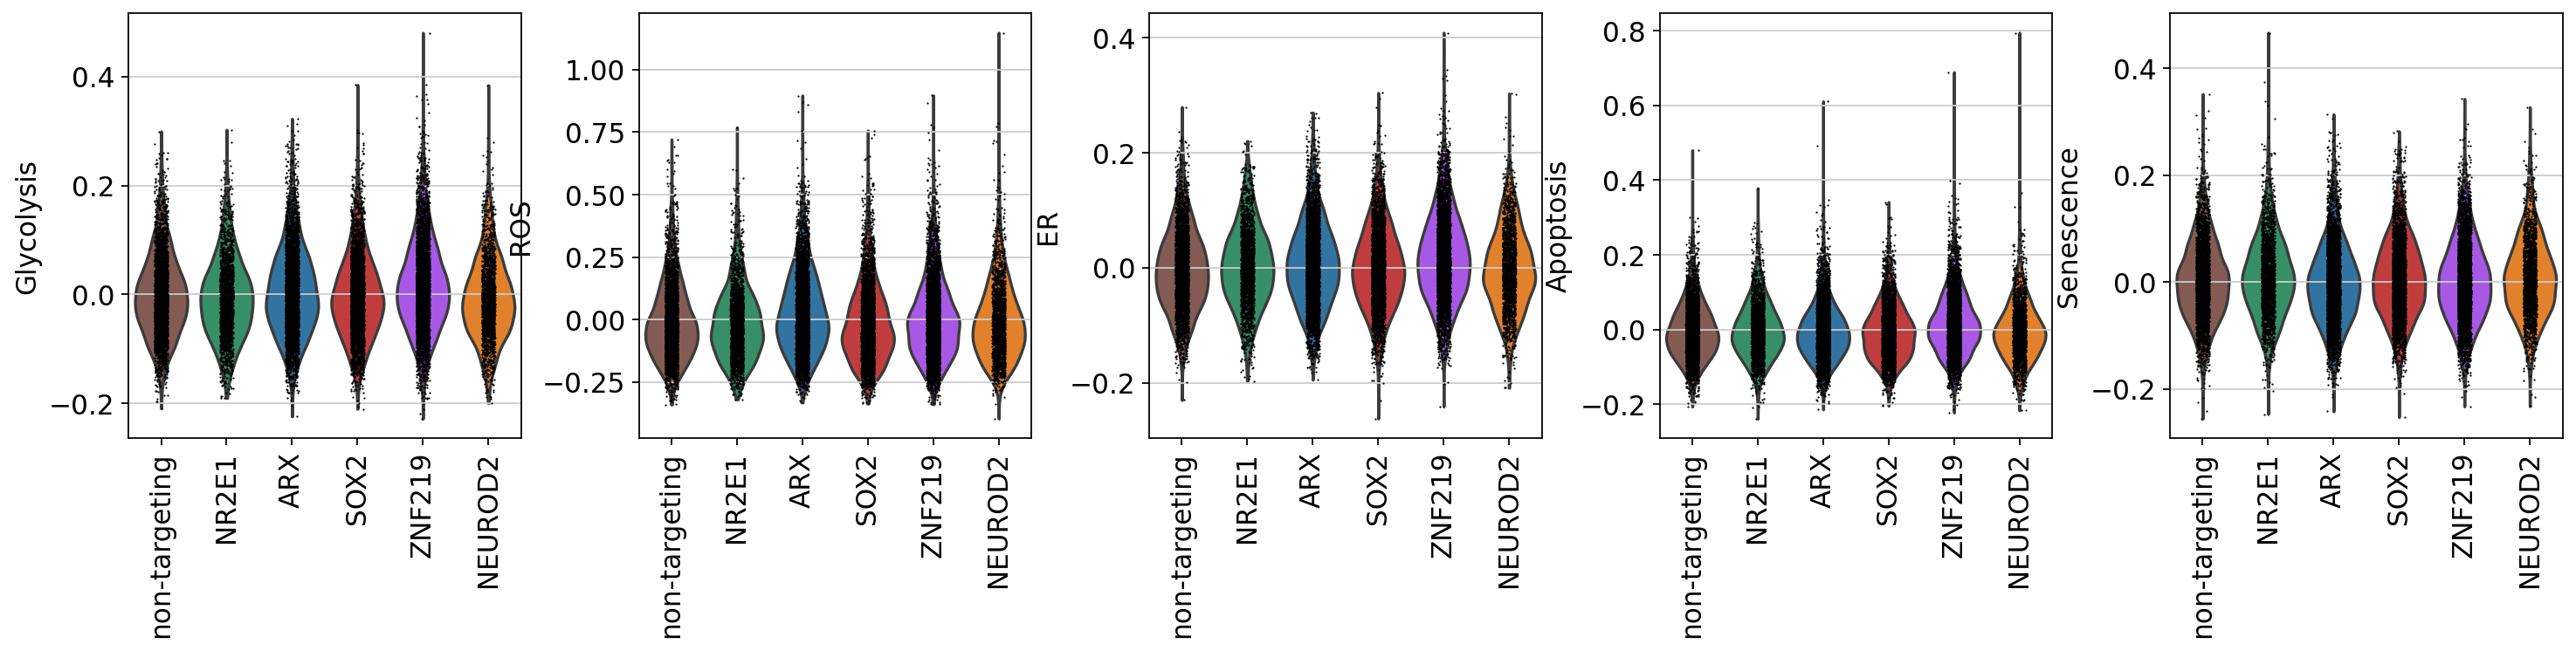

In [7]:
sub = adata[adata.obs['gene_NKS'].isin(['non-targeting','ARX','SOX2','NR2E1','NEUROD2','ZNF219'])]
sc.pl.violin(sub, keys=['Glycolysis','ROS','ER','Apoptosis','Senescence'], groupby='gene_NKS', rotation=90, 
             order = ['non-targeting','NR2E1','ARX','SOX2','ZNF219','NEUROD2'],
             save='IN_stress'
            )

In [ ]:
adata.obs['predictions'] = adata.obs['predictions'].astype('category')
dp = sc.pl.dotplot(adata, ['GAD2','DLX2','LHX6','SST','NFIA','ST18',
                          'PAX6','SP8','PROX1','FBN2','CALB2','SPOCK1','PBX3','TSHZ1','LMO1','RIC3'], 
                   'predictions', cmap='Reds' ,
                   categories_order = ['IN_NFIA/ST18','IN_PAX6/ST18','IN_CALB2/FBN2','IN_CALB2/SPOCK1','IN_PBX3/GRIA1','IN_LMO1/RIC3'],
                                 standard_scale='var',dot_max=0.6, return_fig=True)
dp.add_totals().style(dot_edge_color='black', dot_edge_lw=0.5, cmap='Reds').savefig("./figures/dotplot-IN-HM2D.pdf")

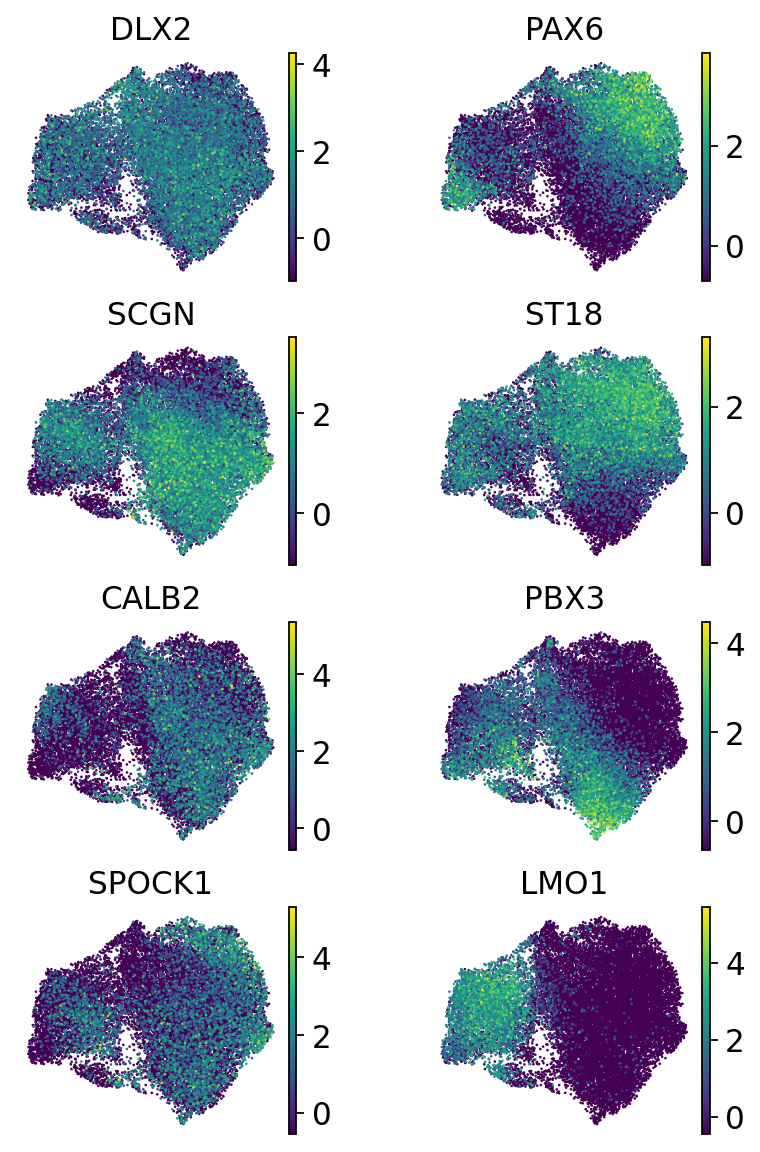

In [72]:
from matplotlib import rcParams
rcParams["figure.figsize"] = (2, 2)
sc.pl.umap(adata, color=['DLX2','PAX6','SCGN','ST18','CALB2','PBX3','SPOCK1','LMO1'],use_raw=False,
           frameon=False, legend_fontsize=13, legend_fontoutline=3,ncols=2 ,save = 'IN_8genes_HM2D')

In [ ]:
from matplotlib import rcParams
rcParams["figure.figsize"] = (2, 2)
sc.pl.umap(adata, color=['DLX2','PAX6','SCGN','ST18','CALB2','PBX3','SPOCK1','LMO1'],use_raw=False,
           frameon=False, legend_fontsize=13, legend_fontoutline=3,ncols=2 ,save = 'IN_8genes_HM2D')

In [3]:
import scanpy as sc
adata_query = sc.read('/wynton/group/pollen/jding/brainchromatin/Li/HM2D_IN_query.h5ad')

In [8]:
adata = sc.read('/wynton/group/pollen/jding/brainchromatin/HM2D/HM2D-filtered_guides.h5ad', compression='gzip')
adata.obs['predictions_IN'] = adata_query.obs["predictions"]
#adata.write('/wynton/scratch/jding/brainchromatin/HM2D/HM2D-filtered_guides.h5ad', compression='gzip')

In [40]:
adata = sc.read('/wynton/group/pollen/jding/brainchromatin/HM2D/HM2D-filtered_guides.h5ad', compression='gzip')
adata.obs['predictions_IN'] = adata_query.obs["predictions"]
adata.write('/wynton/scratch/jding/brainchromatin/HM2D/HM2D-filtered_guides.h5ad', compression='gzip')

In [74]:
adata = sc.read('/wynton/group/pollen/jding/brainchromatin/Li/query_HM2Dall_guides.h5ad')
adata = adata[adata.obs['batch'].isin(['HMD7','HM2ndD7'])]
adata.obs['predictions_IN'] = adata_query.obs["predictions"]
adata.write('/wynton/scratch/jding/brainchromatin/Li/query_HM2Dall_guides.h5ad', compression='gzip')

In [3]:
directory='/wynton/group/pollen/jding/brainchromatin/Li/'
adata_ref = sc.read(os.path.join(directory,'ref_230k.h5ad'), compression='gzip')
adata_query = sc.read(os.path.join(directory,'query_2D.h5ad'), compression='gzip')

In [ ]:
adata=anndata.AnnData.concatenate(adata_ref,adata_query, join='outer', batch_categories=['ref','query']) 

In [ ]:
adata.var

In [23]:
adata = adata.raw.to_adata()
adata.raw = adata
sc.pp.filter_genes(adata,min_cells=10)
sc.pp.normalize_total(adata,exclude_highly_expressed=True)
sc.pp.log1p(adata)
#sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

In [24]:
sc.pp.scale(adata,max_value=10)
sc.pp.pca(adata,n_comps=100)

In [29]:
import scanpy.external as sce
sce.pp.harmony_integrate(adata, 'batch',theta = 6)

2024-05-17 22:56:39,242 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2024-05-17 22:59:03,572 - harmonypy - INFO - sklearn.KMeans initialization complete.
2024-05-17 22:59:06,380 - harmonypy - INFO - Iteration 1 of 10
2024-05-17 23:02:33,457 - harmonypy - INFO - Iteration 2 of 10
2024-05-17 23:05:58,098 - harmonypy - INFO - Iteration 3 of 10
2024-05-17 23:09:18,882 - harmonypy - INFO - Iteration 4 of 10
2024-05-17 23:12:40,470 - harmonypy - INFO - Iteration 5 of 10
2024-05-17 23:16:03,897 - harmonypy - INFO - Iteration 6 of 10
2024-05-17 23:19:30,871 - harmonypy - INFO - Iteration 7 of 10
2024-05-17 23:22:29,759 - harmonypy - INFO - Iteration 8 of 10
2024-05-17 23:25:54,659 - harmonypy - INFO - Iteration 9 of 10
2024-05-17 23:28:43,849 - harmonypy - INFO - Iteration 10 of 10
2024-05-17 23:32:09,888 - harmonypy - INFO - Stopped before convergence


IOStream.flush timed out


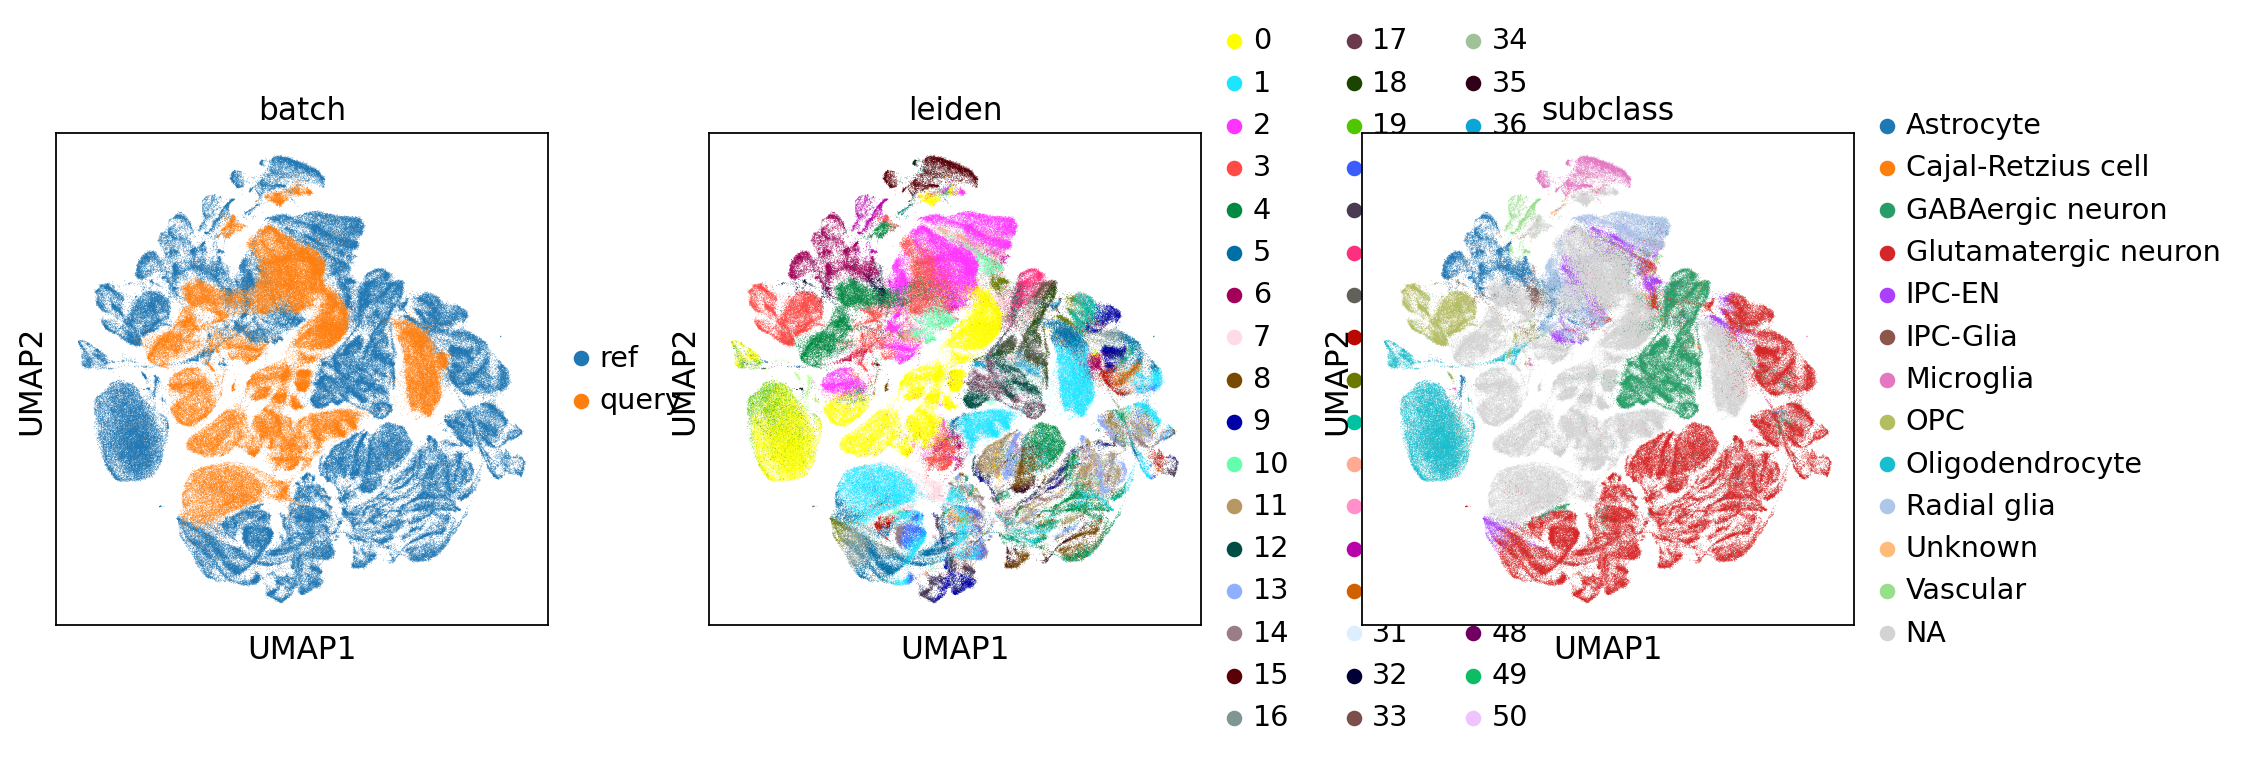

In [30]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=30,use_rep='X_pca_harmony')
sc.tl.umap(adata)
sc.pl.umap(adata,color=['batch','leiden','subclass'])

In [ ]:
ax = sc.pl.umap(adata, color=["batch"], groups=["query"], show=False)

# We can change the 'NA' in the legend that represents all cells outside of the
# specified groups
legend_texts = ax.get_legend().get_texts()
# Find legend object whose text is "NA" and change it
for legend_text in legend_texts:
    if legend_text.get_text() == "NA":
        legend_text.set_text("Wang et al 2023")
    else:
        legend_text.set_text("Current Study")